# Tugas Week 13: Memahami Alur Belajar Neural Network
### **Nama** : Rayhan Christian Wewengkang (2024081005) & Azzah Muthia (2024011014)
### **Mata Kuliah** : Introduction to AI
### **Pertemuan** : WEEK 13


## 1. Studi Kasus dan Dataset

Dalam tugas praktikum ini, dipilih studi kasus **Ulasan Aplikasi (App Review)**. Ulasan aplikasi diklasifikasikan ke dalam dua kelas target:
* **Kelas 1 (Positif)**: Ulasan yang mengekspresikan kepuasan pengguna (misalnya menyebutkan aplikasi bagus, cepat, atau memuaskan).
* **Kelas 0 (Negatif)**: Ulasan yang mengekspresikan keluhan atau kekecewaan (misalnya menyebutkan aplikasi lambat, error, atau lemot).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. PERSIAPAN DATASET
data = {
    "ulasan": [
        "Aplikasi ini sangat membantu dan mudah digunakan",
        "UI dan UX nya bagus banget fiturnya lengkap",
        "Sangat praktis untuk mencatat tugas kuliah harian",
        "Gampang dipahami sangat cocok buat mahasiswa",
        "Update terbaru bikin tambah lancar dan mantap",
        "Sering force close sendiri sangat mengganggu belajar",
        "Banyak bug setelah update tolong segera perbaiki",
        "Loadingnya lama banget dan bikin baterai cepat boros",
        "Susah login aplikasi sering tidak bisa dibuka",
        "Sangat mengecewakan fiturnya banyak yang error"
    ],
    "label": [1, 1, 1, 1, 1, 0, 0, 0, 0, 0] # 1 = Positif, 0 = Negatif
}
df = pd.DataFrame(data)

## 2. VISUALISASI 1: DISTRIBUSI KELAS

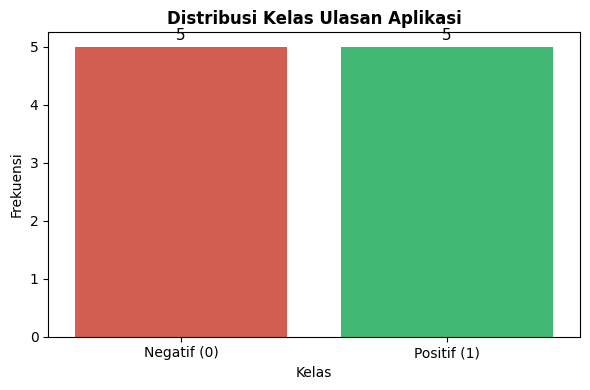

In [8]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df, hue='label', palette=['#E74C3C', '#2ECC71'], legend=False)
plt.title('Distribusi Kelas Ulasan Aplikasi', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['Negatif (0)', 'Positif (1)'])
plt.xlabel('Kelas')
plt.ylabel('Frekuensi')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show() # Mengubah dari savefig ke show untuk render di notebook
plt.close()

# 3. EKSTRAKSI FITUR & VISUALISASI 2: KATA TERBANYAK

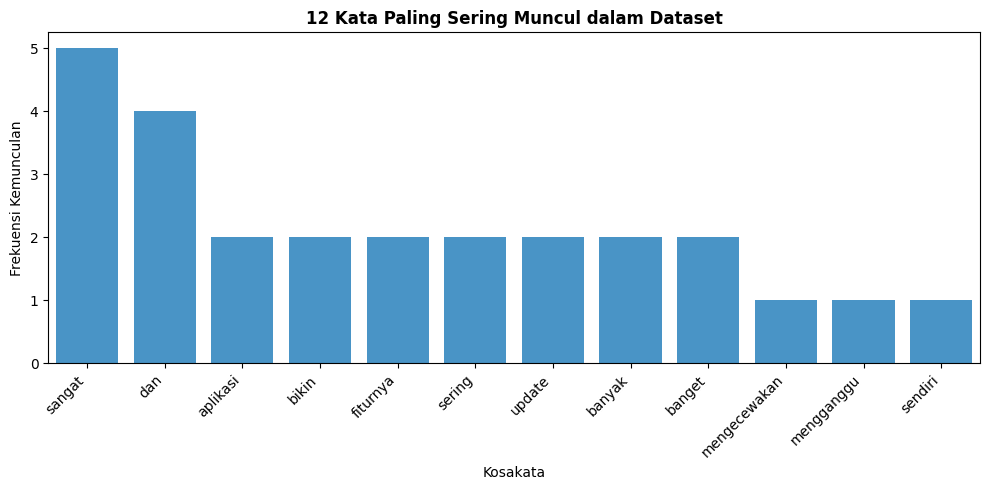

In [9]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["ulasan"])
y = df["label"]

# Menghitung frekuensi kata
kata_frekuensi = X.sum(axis=0).A1
kata_nama = vectorizer.get_feature_names_out()
df_kata = pd.DataFrame({'Kata': kata_nama, 'Frekuensi': kata_frekuensi})
df_kata = df_kata.sort_values(by='Frekuensi', ascending=False).head(12)

plt.figure(figsize=(10, 5))
sns.barplot(x='Kata', y='Frekuensi', data=df_kata, color='#3498DB')
plt.title('12 Kata Paling Sering Muncul dalam Dataset', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frekuensi Kemunculan')
plt.xlabel('Kosakata')
plt.tight_layout()
plt.show()
plt.close()

# 4. TRAINING MODEL & VISUALISASI 3: LOSS CURVE

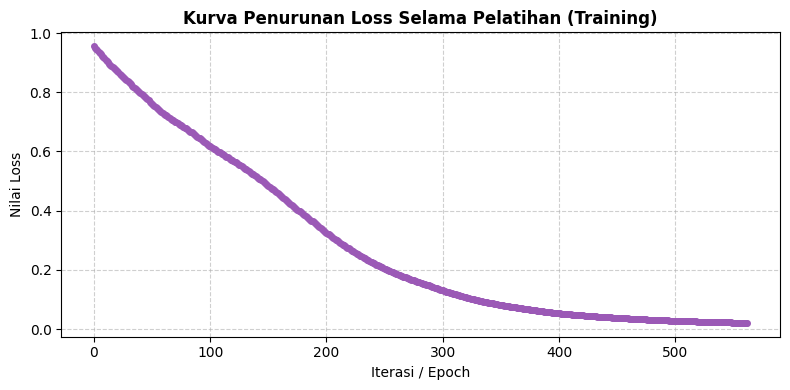

In [12]:
model = MLPClassifier(hidden_layer_sizes=(5,), activation='relu', solver='adam', max_iter=1000, random_state=42)
model.fit(X, y)

# Visualisasi Penurunan Error (Loss Curve)
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_, color='#9B59B6', linewidth=2, marker='o', markersize=4)
plt.title('Kurva Penurunan Loss Selama Pelatihan (Training)', fontsize=12, fontweight='bold')
plt.xlabel('Iterasi / Epoch')
plt.ylabel('Nilai Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
plt.close()

# 5. EVALUASI DAN PREDIKSI

In [13]:
prediksi = model.predict(X)
akurasi = accuracy_score(y, prediksi)
print(f"✅ Training Selesai! Model mencapai akurasi pada data latih: {akurasi * 100}%")

# Uji coba prediksi data baru
ulasan_baru = ["Tugas jadi lebih cepat selesai pakai aplikasi ini"]
X_baru = vectorizer.transform(ulasan_baru)
prediksi_baru = model.predict(X_baru)
probabilitas = model.predict_proba(X_baru)

kelas = "Positif" if prediksi_baru[0] == 1 else "Negatif"
print(f"Ulasan Baru: '{ulasan_baru[0]}'")
print(f"Prediksi: {kelas} | Probabilitas: {probabilitas[0]}")

✅ Training Selesai! Model mencapai akurasi pada data latih: 100.0%
Ulasan Baru: 'Tugas jadi lebih cepat selesai pakai aplikasi ini'
Prediksi: Negatif | Probabilitas: [0.54924382 0.45075618]
